In [2]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [1]:
import yfinance as yf

print("yfinance installed successfully!")
print(yf.__version__)

yfinance installed successfully!
1.7.0


In [2]:
#yfinance is a popular Python library used for downloading historical market data from Yahoo Finance.
#It simplifies the process of accessing financial data for various securities, including stocks, commodities, cryptocurrencies, and more

!pip install yfinance


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
import seaborn as sns
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
#from sklearn import metrics
#from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
#The code fetches historical price data for Bitcoin, Ethereum, Tether, and Binance Coin for the past 5 years and keeps only the Close and Volume columns for each of these cryptocurrencies.
#This cleaned data can then be used for further analysis or machine learning tasks, such as predicting future prices.


btc = yf.Ticker('BTC-USD')
prices1 = btc.history(period='5y')
prices1.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

eth = yf.Ticker('ETH-USD')
prices2 = eth.history(period='5y')
prices2.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

usdt = yf.Ticker('USDT-USD')
prices3 = usdt.history(period='5y')
prices3.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

bnb = yf.Ticker('BNB-USD')
prices4 = bnb.history(period='5y')
prices4.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

In [5]:
#The parameters lsuffix and rsuffix in the join method are used to add suffixes to overlapping column names when joining two DataFrames
# This is necessary to avoid column name conflicts when the two DataFrames have columns with the same name.

p1 = prices1.join(prices2, lsuffix = ' (BTC)', rsuffix = ' (ETH)')
p2 = prices3.join(prices4, lsuffix = ' (USDT)', rsuffix = ' (BNB)')
data = p1.join(p2, lsuffix = '_', rsuffix = '_')

In [6]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-10-09 00:00:00+00:00,54968.222656,32491211414,3575.716797,12707036942,1.000046,67391135102,421.549469,1404867667
2021-10-10 00:00:00+00:00,54771.578125,39527792364,3425.852783,16171746693,1.001018,69927661418,405.069305,1437068558
2021-10-11 00:00:00+00:00,57484.789062,42637331698,3545.354004,18579189588,1.000696,75741431317,413.456207,1473121389
2021-10-12 00:00:00+00:00,56041.058594,41083758949,3492.573242,18109578443,1.000096,73275476508,443.867523,3142304145
2021-10-13 00:00:00+00:00,57401.097656,41684252783,3606.201660,16211275589,1.000097,78117249743,470.749695,5149146903


In [7]:
data.tail()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2026-10-04 00:00:00+00:00,86480.304688,15031650242,2726.509033,5943841130,0.999790,38186771396,795.264099,1195825218
2026-10-05 00:00:00+00:00,85786.593750,30242651384,2711.031494,12303844539,0.999853,71514114557,786.810486,1629945521
2026-10-06 00:00:00+00:00,85557.562500,25245965925,2697.516357,10986122667,0.999845,60953147088,779.615967,1273219160
2026-10-07 00:00:00+00:00,83275.929688,38737709051,2573.527344,20082324906,0.999445,88736239765,772.301270,1545007708
2026-10-09 00:00:00+00:00,82480.062500,42749108224,2494.040039,19003426816,0.999180,93191954432,742.619995,1944022656


In [8]:
data.shape

(1826, 8)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2021-10-09 00:00:00+00:00 to 2026-10-09 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1826 non-null   float64
 1   Volume (BTC)   1826 non-null   int64  
 2   Close (ETH)    1826 non-null   float64
 3   Volume (ETH)   1826 non-null   int64  
 4   Close (USDT)   1826 non-null   float64
 5   Volume (USDT)  1826 non-null   int64  
 6   Close (BNB)    1826 non-null   float64
 7   Volume (BNB)   1826 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.4 KB


In [10]:
data.isna().sum()

Close (BTC)      0
Volume (BTC)     0
Close (ETH)      0
Volume (ETH)     0
Close (USDT)     0
Volume (USDT)    0
Close (BNB)      0
Volume (BNB)     0
dtype: int64

In [11]:
data.describe()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1826.000000,1.826000e+03,1826.000000,1.826000e+03,1826.000000,1.826000e+03,1826.000000,1.826000e+03
mean,58834.578250,3.468105e+10,2511.956446,1.760225e+10,0.999977,6.771998e+10,509.532237,1.631121e+09
std,29834.978231,2.057577e+10,881.602399,1.183597e+10,0.000659,4.223526e+10,219.164124,1.091474e+09
min,15787.284180,5.331173e+09,993.636780,2.081626e+09,0.995872,9.989859e+09,197.042999,2.038465e+08
25%,29410.323730,2.040077e+10,1810.140747,9.459928e+09,0.999679,3.931884e+10,304.741547,9.021106e+08
50%,60824.142578,3.019101e+10,2371.458374,1.503014e+10,1.000062,5.808910e+10,553.516235,1.521219e+09
75%,82285.625000,4.263211e+10,3133.937500,2.173442e+10,1.000285,8.340618e+10,638.678894,2.018161e+09
max,124752.531250,1.817464e+11,4831.348633,9.773662e+10,1.007690,3.443980e+11,1310.214355,1.182039e+10


#Exploratory Data Analysis

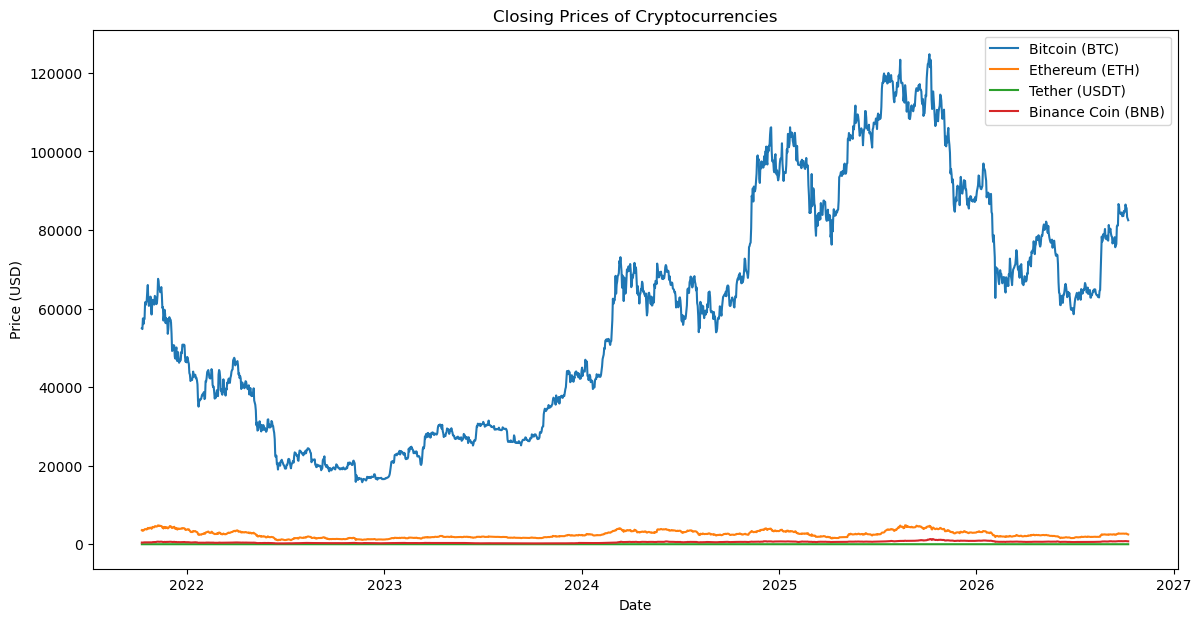

In [12]:
#Visualize the Closing Prices
# create a line plot to visualize the closing prices of all four cryptocurrencies over time:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Close (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Close (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Close (BNB)'], label='Binance Coin (BNB)')
plt.title('Closing Prices of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


<Axes: xlabel='Date'>

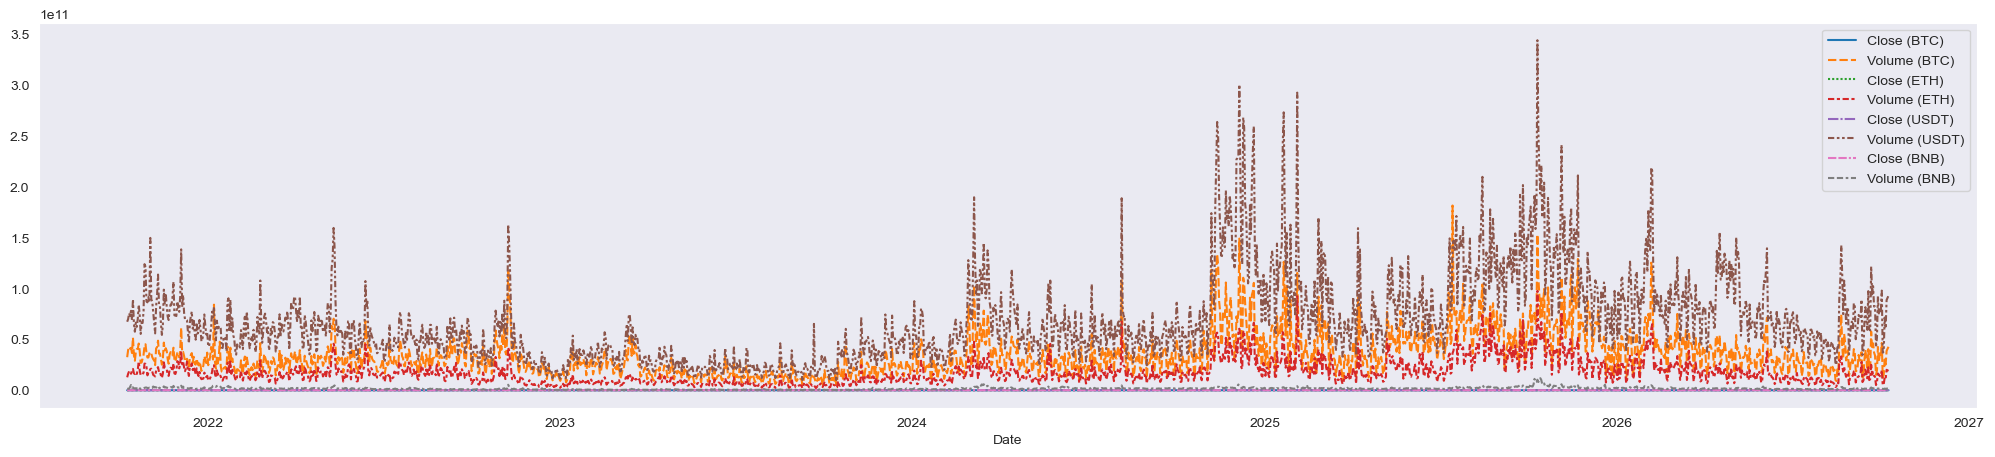

In [13]:
plt.figure(figsize = (25, 5))
sns.set_style('dark')
sns.lineplot(data=data)

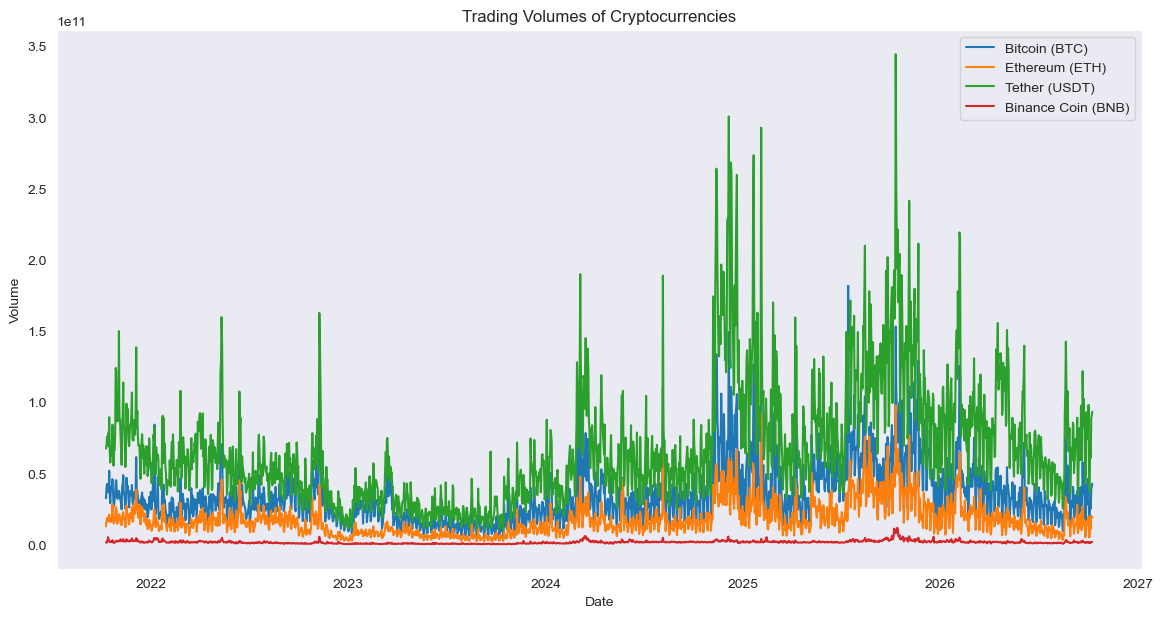

In [14]:
# Visualize the Trading Volumes
#Let's visualize the trading volumes of all four cryptocurrencies:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Volume (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Volume (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Volume (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Volume (BNB)'], label='Binance Coin (BNB)')
plt.title('Trading Volumes of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()


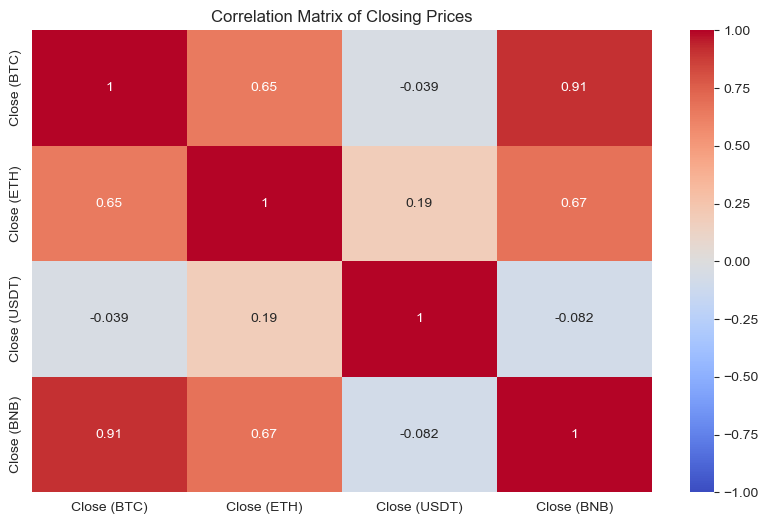

In [15]:
 #Correlation Analysis
#We'll analyze the correlation between the closing prices of the cryptocurrencies:
# Calculate the correlation matrix
corr_matrix = data[['Close (BTC)', 'Close (ETH)', 'Close (USDT)', 'Close (BNB)']].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Closing Prices')
plt.show()


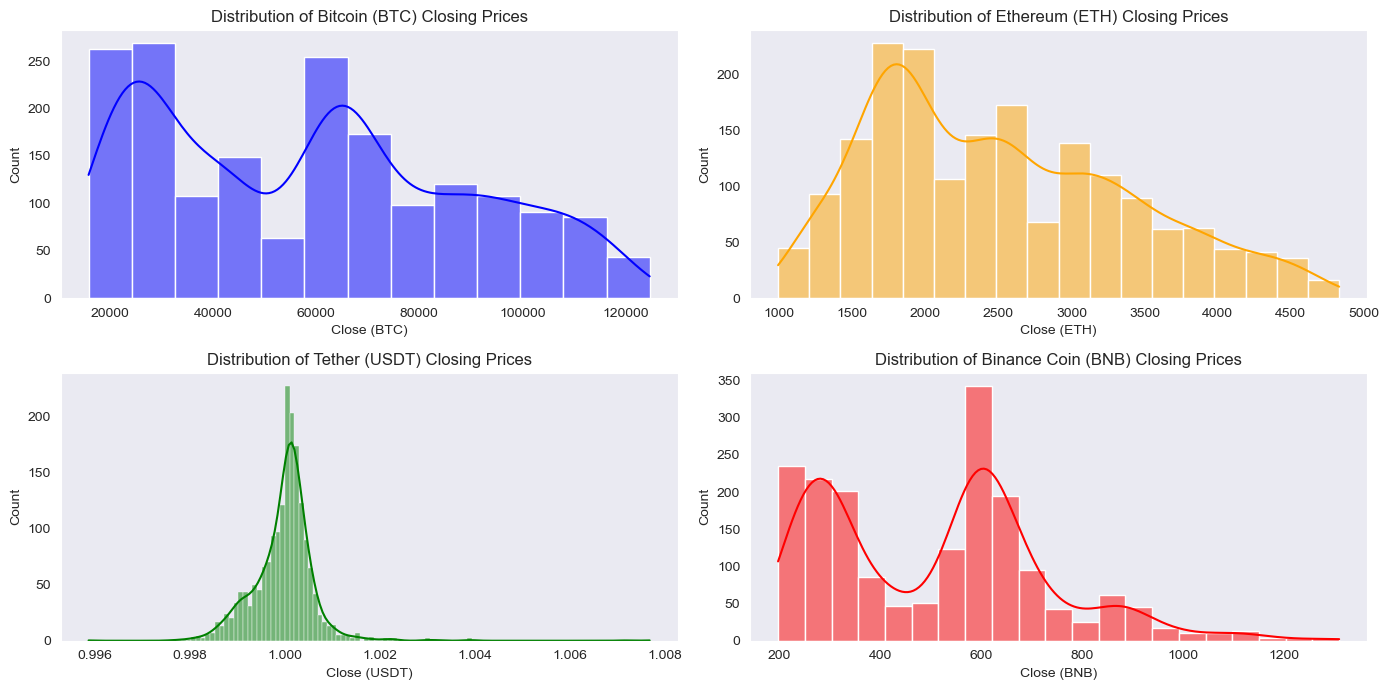

In [16]:
# Distribution of Closing Prices
#Let's plot the distribution of closing prices for each cryptocurrency:
plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(data['Close (BTC)'], kde=True, color='blue')
plt.title('Distribution of Bitcoin (BTC) Closing Prices')

plt.subplot(2, 2, 2)
sns.histplot(data['Close (ETH)'], kde=True, color='orange')
plt.title('Distribution of Ethereum (ETH) Closing Prices')

plt.subplot(2, 2, 3)
sns.histplot(data['Close (USDT)'], kde=True, color='green')
plt.title('Distribution of Tether (USDT) Closing Prices')

plt.subplot(2, 2, 4)
sns.histplot(data['Close (BNB)'], kde=True, color='red')
plt.title('Distribution of Binance Coin (BNB) Closing Prices')

plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'Close (BTC)'}>,
        <Axes: title={'center': 'Volume (BTC)'}>,
        <Axes: title={'center': 'Close (ETH)'}>,
        <Axes: title={'center': 'Volume (ETH)'}>],
       [<Axes: title={'center': 'Close (USDT)'}>,
        <Axes: title={'center': 'Volume (USDT)'}>,
        <Axes: title={'center': 'Close (BNB)'}>,
        <Axes: title={'center': 'Volume (BNB)'}>]], dtype=object)

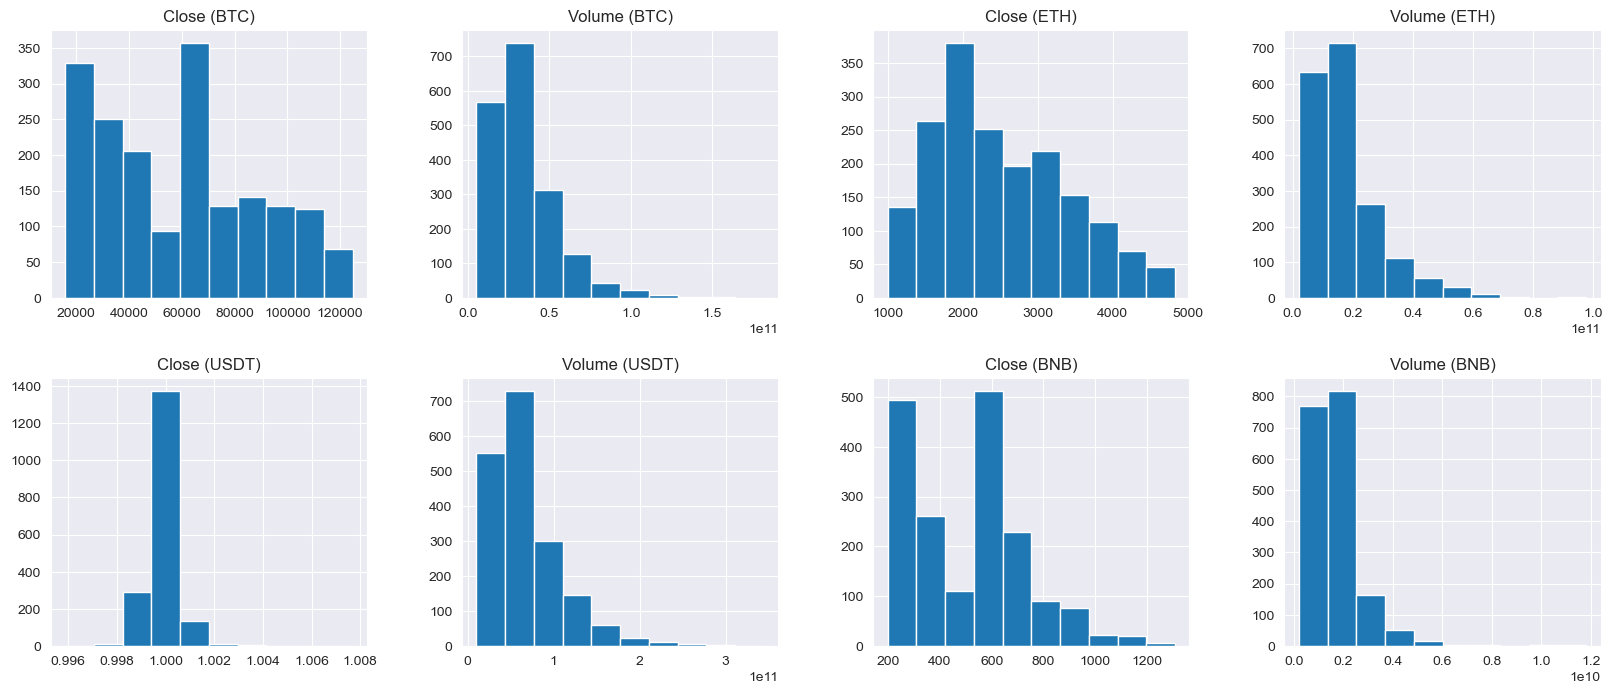

In [17]:
data.hist(figsize=(20, 8), layout=(2, 4))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

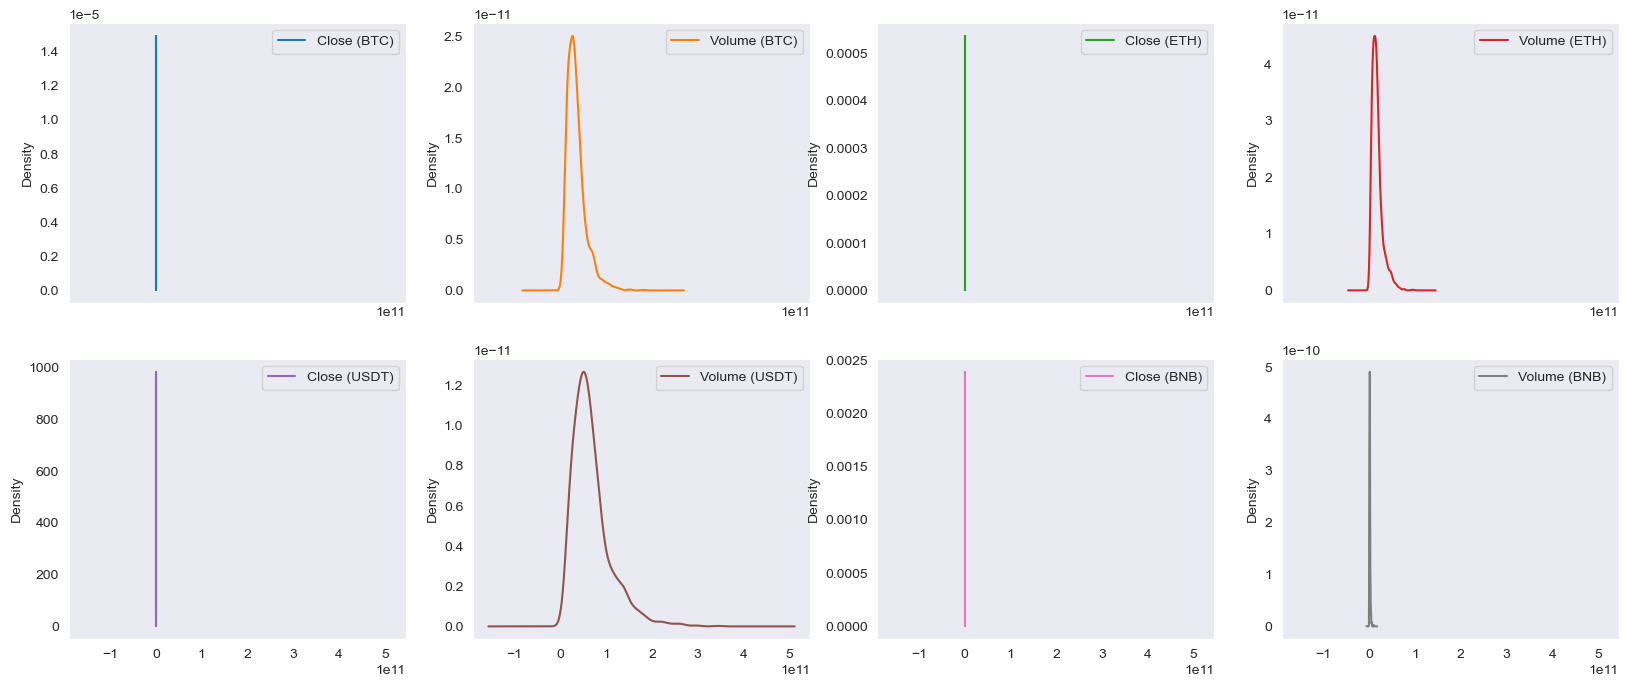

In [18]:
data.plot(kind = "kde", subplots = True, layout = (2, 4), figsize = (20, 8))

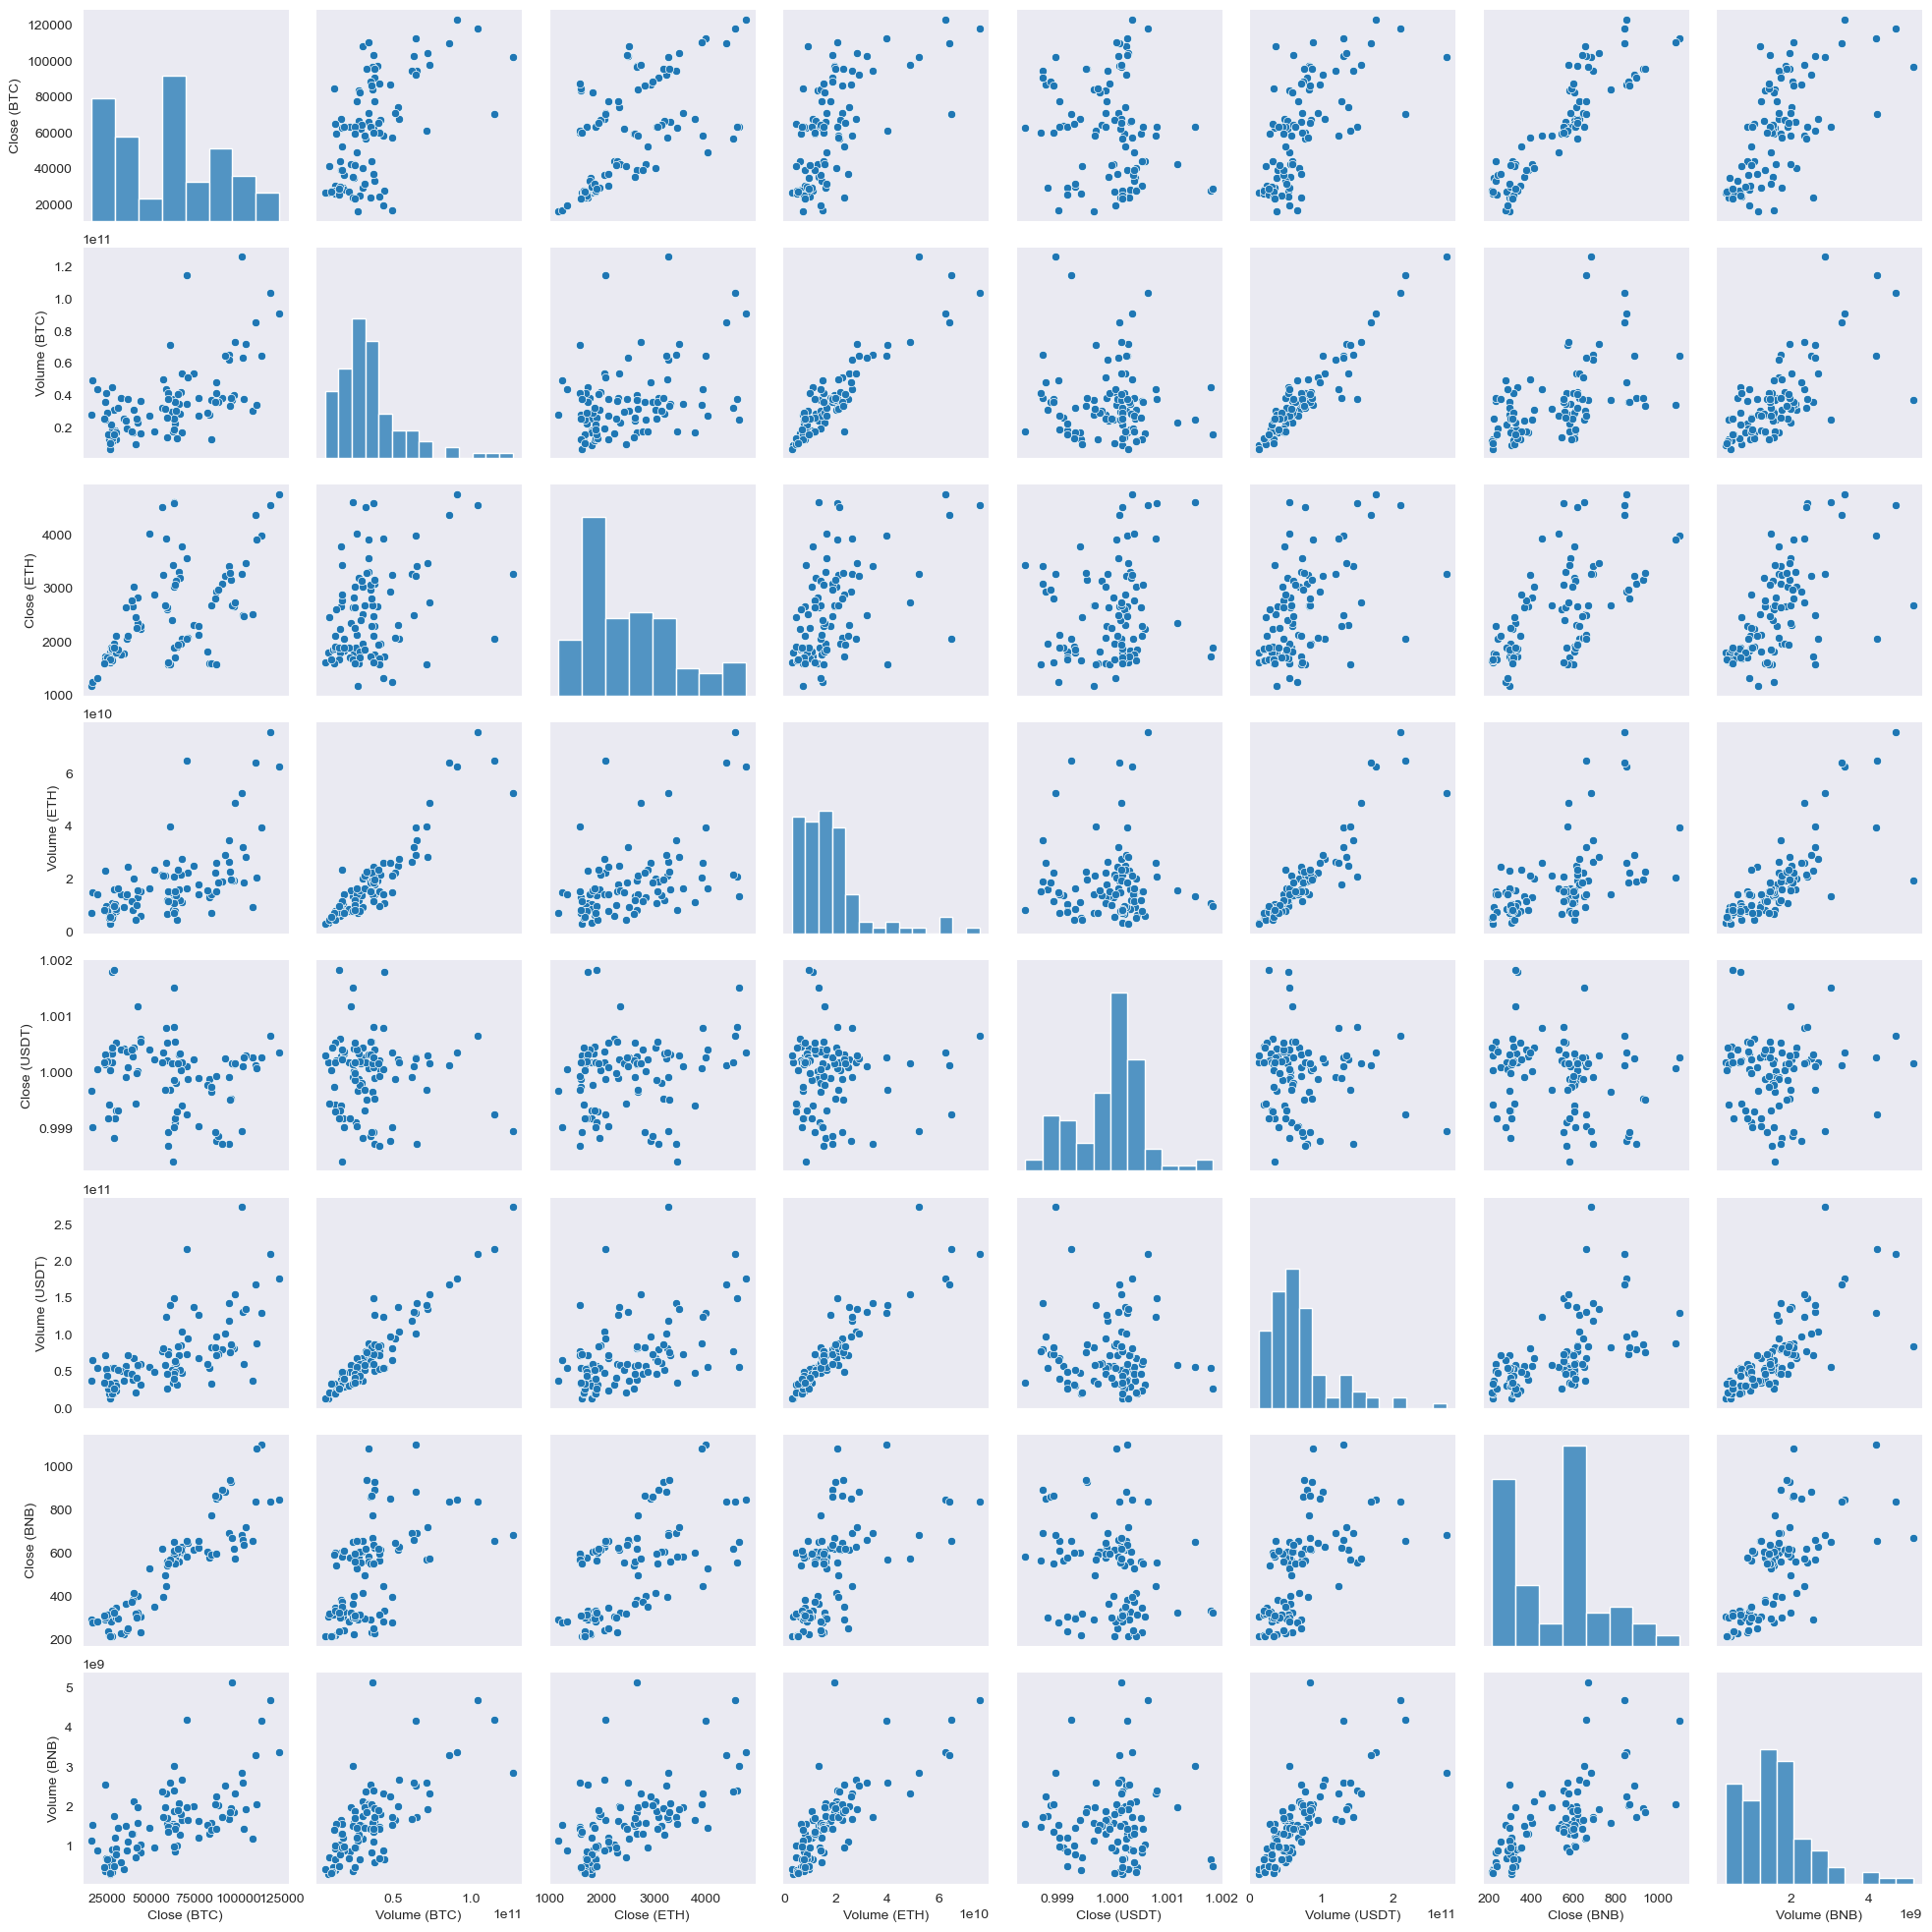

In [19]:
sns.pairplot(data.sample(n=100));

#Data Pre-processing

In [20]:
X = data.drop(columns = ['Close (BTC)'], axis = 1)
Y = data.loc[:, 'Close (BTC)']

In [21]:
X.head()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2021-10-09 00:00:00+00:00,32491211414,3575.716797,12707036942,1.000046,67391135102,421.549469,1404867667
2021-10-10 00:00:00+00:00,39527792364,3425.852783,16171746693,1.001018,69927661418,405.069305,1437068558
2021-10-11 00:00:00+00:00,42637331698,3545.354004,18579189588,1.000696,75741431317,413.456207,1473121389
2021-10-12 00:00:00+00:00,41083758949,3492.573242,18109578443,1.000096,73275476508,443.867523,3142304145
2021-10-13 00:00:00+00:00,41684252783,3606.201660,16211275589,1.000097,78117249743,470.749695,5149146903


In [22]:
X.tail()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-10-04 00:00:00+00:00,15031650242,2726.509033,5943841130,0.999790,38186771396,795.264099,1195825218
2026-10-05 00:00:00+00:00,30242651384,2711.031494,12303844539,0.999853,71514114557,786.810486,1629945521
2026-10-06 00:00:00+00:00,25245965925,2697.516357,10986122667,0.999845,60953147088,779.615967,1273219160
2026-10-07 00:00:00+00:00,38737709051,2573.527344,20082324906,0.999445,88736239765,772.301270,1545007708
2026-10-09 00:00:00+00:00,42749108224,2494.040039,19003426816,0.999180,93191954432,742.619995,1944022656


In [23]:
Y.head()


Date
2021-10-09 00:00:00+00:00    54968.222656
2021-10-10 00:00:00+00:00    54771.578125
2021-10-11 00:00:00+00:00    57484.789062
2021-10-12 00:00:00+00:00    56041.058594
2021-10-13 00:00:00+00:00    57401.097656
Name: Close (BTC), dtype: float64

In [24]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [25]:
# Print the shapes of the resulting datasets
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {Y_train.shape}')
print(f'y_test shape: {Y_test.shape}')

X_train shape: (1460, 7)
X_test shape: (366, 7)
y_train shape: (1460,)
y_test shape: (366,)


In [26]:
#SelectKBest
#SelectKBest is a feature selection method provided by scikit-learn (sklearn) that selects the top k features based on a specified scoring function.
#This function evaluates each feature independently and selects those that have the strongest relationship with the target variable.

#Parameters
#k: Specifies the number of top features to select. In your case, k=4 indicates that you want to select the top 4 features

from sklearn.feature_selection import SelectKBest

fs = SelectKBest(k=4)
X_train = fs.fit_transform(X_train, Y_train)
X_test = fs.transform(X_test)

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [27]:
mask = fs.get_support()
selected_features = X.columns[mask]
print("Selected Features:", selected_features) 

Selected Features: Index(['Close (USDT)', 'Volume (USDT)', 'Close (BNB)', 'Volume (BNB)'], dtype='object')


In [28]:
X_train


array([[1.00028706e+00, 1.08840158e+11, 6.30322449e+02, 1.58539132e+09],
       [1.00005698e+00, 8.23078480e+10, 8.62403992e+02, 2.03096836e+09],
       [9.99664009e-01, 7.45304267e+10, 1.09464233e+03, 2.13818559e+09],
       ...,
       [1.00019801e+00, 1.09498516e+11, 6.16524475e+02, 1.50773210e+09],
       [1.00014198e+00, 3.45534960e+10, 3.21674988e+02, 1.05753080e+09],
       [9.99426007e-01, 2.00707361e+10, 2.18646393e+02, 3.94620698e+08]])

In [29]:
#MinMaxScaler is a preprocessing method in scikit-learn that transforms features by scaling them to a specified range.
# It's often used when your data needs to be normalized within a specific range to ensure all features contribute equally to the analysis.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# implementation of 10 different regression algorithms using scikit-learn. Each algorithm is trained and evaluated on a sample dataset:

#Import Libraries and Generate Sample Data

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

----- Linear Regression -----
Mean Squared Error (MSE): 127203783.04491408
R-squared: 0.8554352141466334

----- Ridge Regression -----
Mean Squared Error (MSE): 128561697.5912604
R-squared: 0.8538919689624047

----- Lasso Regression -----
Mean Squared Error (MSE): 127164148.39123456
R-squared: 0.8554802582096667

----- ElasticNet Regression -----
Mean Squared Error (MSE): 750823729.9620996
R-squared: 0.14670248684921716

----- Support Vector Regression (SVR) -----
Mean Squared Error (MSE): 869203894.2971462
R-squared: 0.01216558317600036

----- Decision Tree Regression -----
Mean Squared Error (MSE): 119050659.31448928
R-squared: 0.8647010909775819

----- Random Forest Regression -----
Mean Squared Error (MSE): 62632791.678970136
R-squared: 0.9288189714194914

----- Gradient Boosting Regression -----
Mean Squared Error (MSE): 63099744.13162704
R-squared: 0.9282882884499588

----- K-Nearest Neighbors Regression -----
Mean Squared Error (MSE): 69018376.50831373
R-squared: 0.9215618704016

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


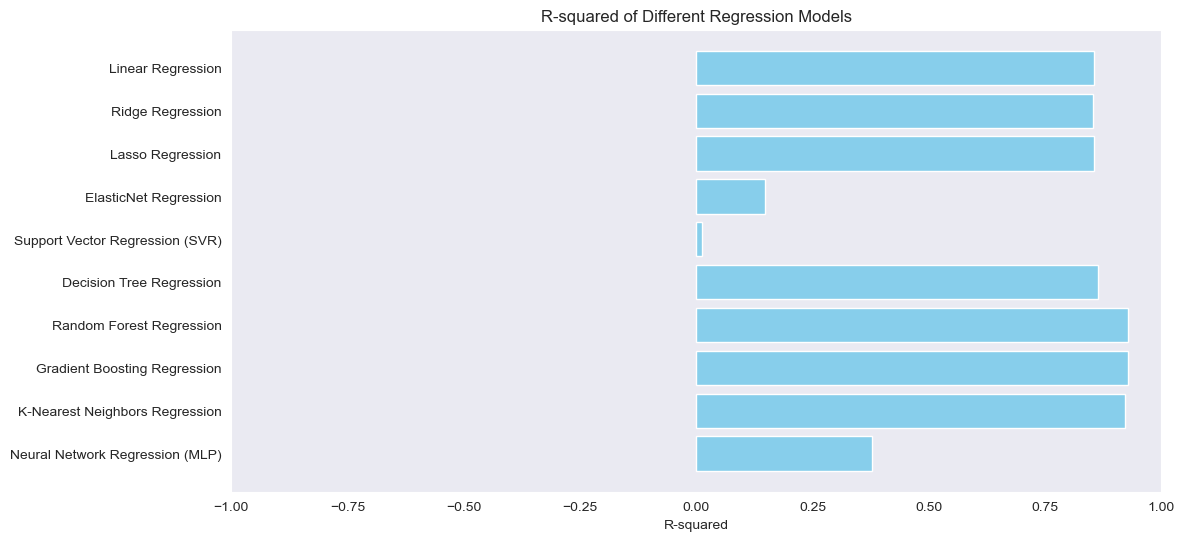

In [31]:

#Define Models and Perform Training and Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Support Vector Regression (SVR)': SVR(kernel='rbf'),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'Neural Network Regression (MLP)': MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam')
}

# Train and evaluate each model
results = {'Model': [], 'MSE': [], 'R-squared': []}

for name, model in models.items():
    # Train the model
    model.fit(X_train, Y_train)

    # Predict on test set
    Y_pred = model.predict(X_test)

    # Evaluate model
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    # Store results
    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R-squared'].append(r2)

    # Print results
    print(f"----- {name} -----")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared: {r2}")
    print()

# Convert results to DataFrame for visualization
results_df = pd.DataFrame(results)
print(results_df)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R-squared'], color='skyblue')
plt.xlabel('R-squared')
plt.title('R-squared of Different Regression Models')
plt.xlim(-1, 1)
plt.gca().invert_yaxis()
plt.show()


#Random Forest Regression is a powerful and versatile algorithm suitable for various regression tasks, offering robust performance and the ability to handle complex data relationships

#Saving the Model


In [32]:
import pickle
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Generate sample data
X, Y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=0)


# Scale the features (optional but recommended for some algorithms)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=0)

# Train the model
model_rf.fit(X_train, Y_train)

# Save the model to a file
filename = 'random_forest_model.pkl'
pickle.dump(model_rf, open(filename, 'wb'))

# Save scaler to a file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Load the model from the file
loaded_model = pickle.load(open(filename, 'rb'))

# Predict using the loaded model
Y_pred = loaded_model.predict(X_test)

# Evaluate the loaded model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Loaded Random Forest Regression - Mean Squared Error (MSE): {mse}")
print(f"Loaded Random Forest Regression - R-squared: {r2}")


Loaded Random Forest Regression - Mean Squared Error (MSE): 65127430.27104229
Loaded Random Forest Regression - R-squared: 0.9259838600319856
